In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Flatten,Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical # this is used for onehot encoding 
import matplotlib.pyplot as plt
import numpy as np


In [29]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()
print(x_train.shape)
print(x_test.shape)
print(x_train.min(), x_train.max())

(60000, 28, 28)
(10000, 28, 28)
0 255


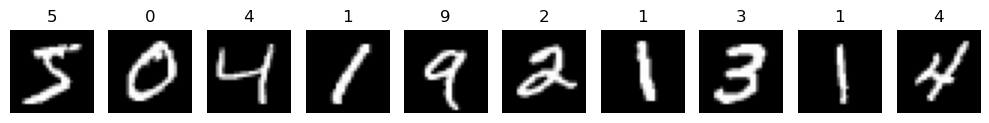

In [30]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i],cmap="grey")
    plt.axis("off")
    plt.title(str(y_train[i]))
plt.tight_layout()
plt.show()

In [ ]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encode
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print((x_train.min():.1f),(x_train.max():.1f))
print(f"Label '3' one-hot → {y_train_cat[np.where(y_train==3)[0][0]]}")

Pixel range after normalisation: 0.0 – 1.0
Label '3' one-hot → [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [54]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    # Input(shape=(28,28)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy", 
    metrics = ["accuracy"]

)
history = model.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1,   
    verbose=1,
    )


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9116 - loss: 0.3160 - val_accuracy: 0.9548 - val_loss: 0.1562
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9550 - loss: 0.1519 - val_accuracy: 0.9673 - val_loss: 0.1161
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9682 - loss: 0.1077 - val_accuracy: 0.9735 - val_loss: 0.0985
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9742 - loss: 0.0849 - val_accuracy: 0.9720 - val_loss: 0.0967
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9791 - loss: 0.0701 - val_accuracy: 0.9753 - val_loss: 0.0917


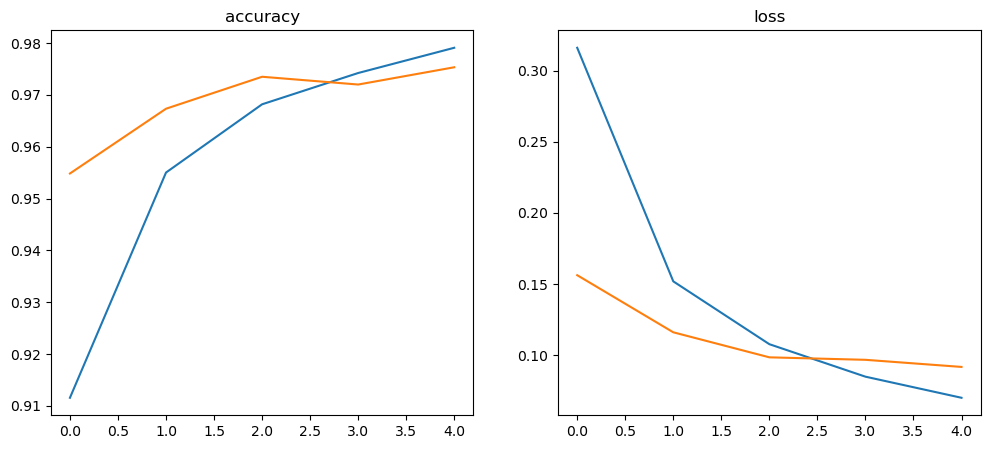

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title('accuracy')

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title('loss')
plt.show()

In [58]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0924
Test accuracy: 0.9714


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step


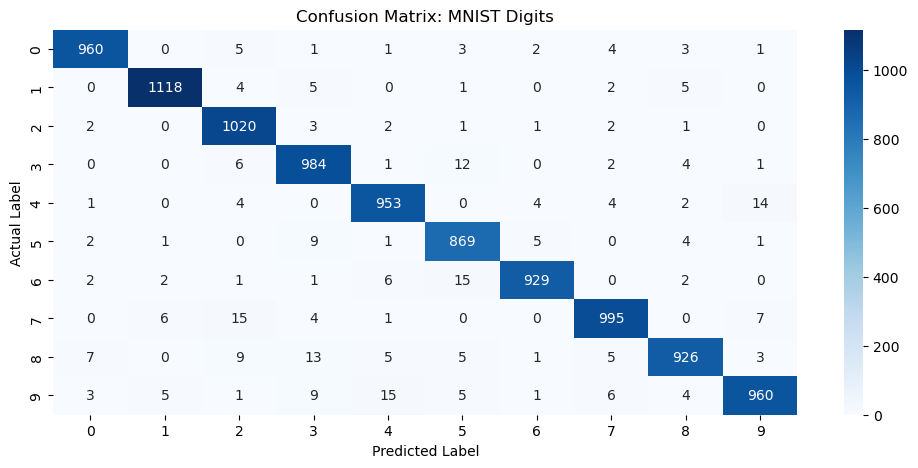

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob,axis=1)

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(12,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: MNIST Digits')
plt.show()